# Porcentajes de cobertura por polígono

In [117]:
import geopandas as gpd
import pandas as pd

# A) Carga de capas
gdf = gpd.read_file("D:\Semestre 2025-1\Analisis Geoespacial\SHP\Amenaza_con_Morfometria.shp")
cov = gpd.read_file("D:\Semestre 2025-1\Analisis Geoespacial\SHP\Coberturas_MedellinZonaUrbana.shp")

# B) Unificar CRS
cov = cov.to_crs(gdf.crs)

# C) Crear ID único de polígono
gdf = gdf.reset_index().rename(columns={'index':'poly_id'})

# D) Intersección polígono × cobertura
inter = gpd.overlay(
    gdf[['poly_id','geometry']], 
    cov[['tipo','geometry']], 
    how='intersection'
)

# E) Área de cada intersección
inter['area_int'] = inter.geometry.area

# F) Sumar área por (poly_id, clase de cobertura)
areas = (
    inter
    .groupby(['poly_id','tipo'])['area_int']
    .sum()
    .reset_index()
)

# G) Area total de cada polígono (para porcentaje)
gdf['area_poly'] = gdf.geometry.area

# H) Pivot a formato ancho y cálculo de porcentaje
pivot = (
    areas
    .pivot(index='poly_id', columns='tipo', values='area_int')
    .fillna(0)
)
# divide por área total y multiplica por 100
for cov_type in pivot.columns:
    gdf[f"pct_cov_{cov_type}"] = pivot[cov_type] / gdf['area_poly'] * 100

# Ahora gdf tiene columnas pct_cov_<tipo> con el % de cada cobertura


<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_52780\515071701.py:5: SyntaxWarning: invalid escape sequence '\S'
  gdf = gpd.read_file("D:\Semestre 2025-1\Analisis Geoespacial\SHP\Amenaza_con_Morfometria.shp")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_52780\515071701.py:6: SyntaxWarning: invalid escape sequence '\S'
  cov = gpd.read_file("D:\Semestre 2025-1\Analisis Geoespacial\SHP\Coberturas_MedellinZonaUrbana.shp")


In [118]:
# 5) Prints para revisar resultados
cov_cols = [col for col in gdf.columns if col.startswith('pct_cov_')]
print("=== Estadísticos de Porcentaje de Cobertura ===")
print(gdf[cov_cols].describe(), "\n")

=== Estadísticos de Porcentaje de Cobertura ===
       pct_cov_Bosques y Áreas Seminaturales  pct_cov_Superficies de Agua  \
count                             506.000000                   506.000000   
mean                               30.208910                     0.196669   
std                                28.727131                     3.137336   
min                                 0.000000                     0.000000   
25%                                 2.911843                     0.000000   
50%                                22.577812                     0.000000   
75%                                51.751988                     0.000000   
max                               100.000000                    68.736438   

       pct_cov_Territorios Agrícolas  pct_cov_Territorios Artificializados  
count                     506.000000                            506.000000  
mean                        2.865933                             66.732465  
std                        

In [119]:
import geopandas as gpd

inv = gpd.read_file(r"D:/Semestre 2025-1/Analisis Geoespacial/SHP/Inventario_inundaciones_lluvias_MedellinZonaUrbana.shp")

# --- 2) Unificar CRS ---
inv = inv.to_crs(gdf.crs)

# --- 3) Spatial join nearest con max_distance ---
joined = gpd.sjoin_nearest(
    inv[['geometry']],
    gdf[['poly_id','geometry']],
    how="left",               # o "inner" si quieres descartar puntos sin vecino
    max_distance=100,
    distance_col="dist"
)

# 4) Inspecciona las columnas y los primeros registros
print("Columnas en 'joined':", joined.columns.tolist())
print("Primeros 5 registros de 'joined':")
print(joined.head())

# --- 5) Agrupar para contar cuántos eventos por polígono ---
# Asegúrate aquí de usar el nombre exacto de la columna que importe el poly_id
counts = joined.groupby('poly_id').size().rename('count_events')
print("\nConteo provisional por poly_id:")
print(counts.head())

# --- 6) Merge con tu GeoDataFrame de polígonos ---
gdf = gdf.merge(counts, on='poly_id', how='left')
gdf['count_events'] = gdf['count_events'].fillna(0).astype(int)

# --- 7) Prints finales para revisar resultados ---
print("\n=== Estadísticos de count_events ===")
print(gdf['count_events'].describe())

print("\n=== Primeras 5 filas de gdf con count_events ===")
print(gdf[['poly_id','count_events']].head())


Columnas en 'joined': ['geometry', 'index_right', 'poly_id', 'dist']
Primeros 5 registros de 'joined':
                          geometry  index_right  poly_id       dist
0  POINT (4718274.578 2252102.081)          NaN      NaN        NaN
1  POINT (4716329.273 2253478.046)        188.0    188.0  50.328077
2  POINT (4718425.865 2253980.604)          NaN      NaN        NaN
3  POINT (4717785.088 2254716.264)        112.0    112.0  16.363295
4  POINT (4717463.667 2254869.781)        112.0    112.0  49.688413

Conteo provisional por poly_id:
poly_id
0.0     1
3.0     5
10.0    2
21.0    3
30.0    1
Name: count_events, dtype: int64

=== Estadísticos de count_events ===
count    506.000000
mean       0.456522
std        1.663554
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       13.000000
Name: count_events, dtype: float64

=== Primeras 5 filas de gdf con count_events ===
   poly_id  count_events
0        0             1
1        1             0
2      

In [120]:
gdf.to_file("Amenaza_Enriquecida.shp")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_52780\2099972178.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file("Amenaza_Enriquecida.shp")
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field fecha_adop create as date field, though DateTime requested.
  ogr_write(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field fecha_actu create as date field, though DateTime requested.
  ogr_write(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'pct_cov_Bosques y Áreas Seminaturales' to 'pct_cov_Bo'
  ogr_write(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'pct_cov_Superficies de Agua' to 'pct_cov_Su'
  ogr_write(
C:\Users\Usuario\AppData\Roaming\Pytho

In [1]:
import geopandas as gpd
gdf = gpd.read_file("Amenaza_Enriquecida.shp")
print(gdf.columns.tolist())

['poly_id', 'codigo', 'categoria', 'grado_amen', 'categoria_', 'subcategor', 'fecha_adop', 'fecha_actu', 'Shape_Leng', 'Shape_Area', 'Aspecto_me', 'Curvatura_', 'Elevacion_', 'Pendiente_', 'TRI_mean', 'TPI_mean', 'area_poly', 'pct_cov_Bo', 'pct_cov_Su', 'pct_cov_Te', 'pct_cov__1', 'count_even', 'geometry']


In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

# Reproyecta tu gdf (polígonos) a Web Mercator  
gdf_3857 = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
gdf_3857.plot(
    ax=ax,
    facecolor="none",
    edgecolor="blue",
    linewidth=1,
    label="Zonas de amenaza"
)
# Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=12
)
ax.set_title("Polígonos de amenaza por inundación", fontsize=14)
ax.legend(loc="upper right")
ax.set_axis_off()
plt.tight_layout()
plt.show()


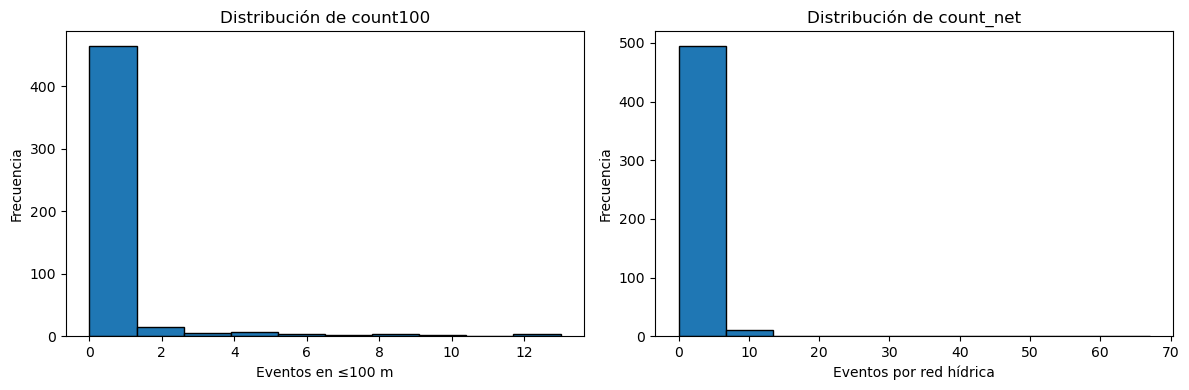

In [39]:
import matplotlib.pyplot as plt

# — 1) Histograma de conteos —
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# a) Conteo a 100 m
axes[0].hist(gdf['count100'], bins=10, edgecolor='black')
axes[0].set_title('Distribución de count100')
axes[0].set_xlabel('Eventos en ≤100 m')
axes[0].set_ylabel('Frecuencia')

# b) Conteo por red hídrica
axes[1].hist(gdf['count_net'], bins=10, edgecolor='black')
axes[1].set_title('Distribución de count_net')
axes[1].set_xlabel('Eventos por red hídrica')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


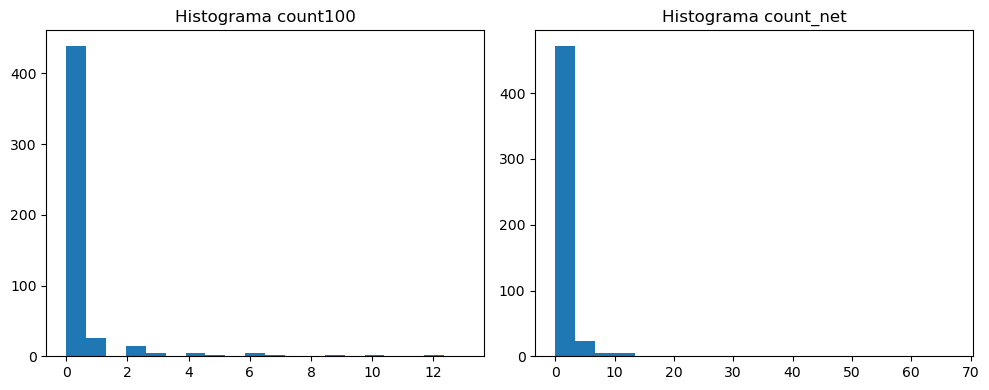

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log1p(count100)                Number of Observations:         506
Mean dependent var  :      0.1695                Number of Variables   :          11
S.D. dependent var  :      0.4892                Degrees of Freedom    :         495
R-squared           :      0.0243
Adjusted R-squared  :      0.0046
Sum squared residual:     117.916                F-statistic           :      1.2354
Sigma-square        :       0.238                Prob(F-statistic)     :      0.2654
S.E. of regression  :       0.488                Log likelihood        :    -349.472
Sigma-square ML     :       0.233                Akaike info criterion :     720.943
S.E of regression ML:      0.4827                Schwarz criterion     :     767.435

---------------------------------------------------------

In [40]:
# —————————————————————————————————
# 1) Histogramas
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].hist(gdf['count100'], bins=20)
axes[0].set_title('Histograma count100')
axes[1].hist(gdf['count_net'], bins=20)
axes[1].set_title('Histograma count_net')
plt.tight_layout()
plt.show()

# 2) Ajuste OLS simple
from spreg import OLS
# y = log1p(count100), Xs = matriz de predictores estandarizados
ols = OLS(y, Xs, name_y='log1p(count100)', name_x=X_vars)
print(ols.summary)

# 3) Moran’s I de residuos OLS
from esda.moran import Moran
m_ols = Moran(ols.u.flatten(), w)
print(f"Moran’s I residuos OLS: I={m_ols.I:.3f}, p={m_ols.p_sim:.3f}")
# —————————————————————————————————


# Cluster

In [6]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Verifica que count_events exista
print("Columnas disponibles:", gdf.columns.tolist())

# 1) Variables a usar
morf_cols = ['Elevacion_','Pendiente_','Aspecto_me','Curvatura_','TPI_mean','TRI_mean']
cov_cols  = [c for c in gdf.columns if c.startswith('pct_cov_')]
all_cols  = morf_cols + cov_cols + ['count_even']

print("Usando para clustering:", all_cols)

# 2) Matriz de atributos y escalado
X  = gdf[all_cols].fillna(0).values
Xs = StandardScaler().fit_transform(X)

# 3) DBSCAN espacial
coords = np.vstack([gdf.geometry.centroid.x, gdf.geometry.centroid.y]).T
db = DBSCAN(eps=700, min_samples=5).fit(coords)
gdf['cluster_spatial'] = db.labels_

print("Clusters espaciales (DBSCAN):", 
      len(set(db.labels_)) - (1 if -1 in db.labels_ else 0))
print(gdf['cluster_spatial'].value_counts())

# 4) KMeans atributos k=3
kmeans = KMeans(n_clusters=3, random_state=0).fit(Xs)
gdf['cluster_attr'] = kmeans.labels_

print("Clusters por atributos (KMeans):")
print(gdf['cluster_attr'].value_counts())

# 5) Revisa resultados
print(gdf[['cluster_spatial','cluster_attr']].head())


Columnas disponibles: ['poly_id', 'codigo', 'categoria', 'grado_amen', 'categoria_', 'subcategor', 'fecha_adop', 'fecha_actu', 'Shape_Leng', 'Shape_Area', 'Aspecto_me', 'Curvatura_', 'Elevacion_', 'Pendiente_', 'TRI_mean', 'TPI_mean', 'area_poly', 'pct_cov_Bo', 'pct_cov_Su', 'pct_cov_Te', 'pct_cov__1', 'count_even', 'geometry', 'count100']
Usando para clustering: ['Elevacion_', 'Pendiente_', 'Aspecto_me', 'Curvatura_', 'TPI_mean', 'TRI_mean', 'pct_cov_Bo', 'pct_cov_Su', 'pct_cov_Te', 'pct_cov__1', 'count_even']
Clusters espaciales (DBSCAN): 8
cluster_spatial
 0    313
 1     83
 7     27
 6     25
 4     19
-1     16
 2     12
 5      6
 3      5
Name: count, dtype: int64
Clusters por atributos (KMeans):
cluster_attr
1    268
2    125
0    113
Name: count, dtype: int64
   cluster_spatial  cluster_attr
0                0             2
1                0             1
2                0             1
3                0             1
4                0             2


C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


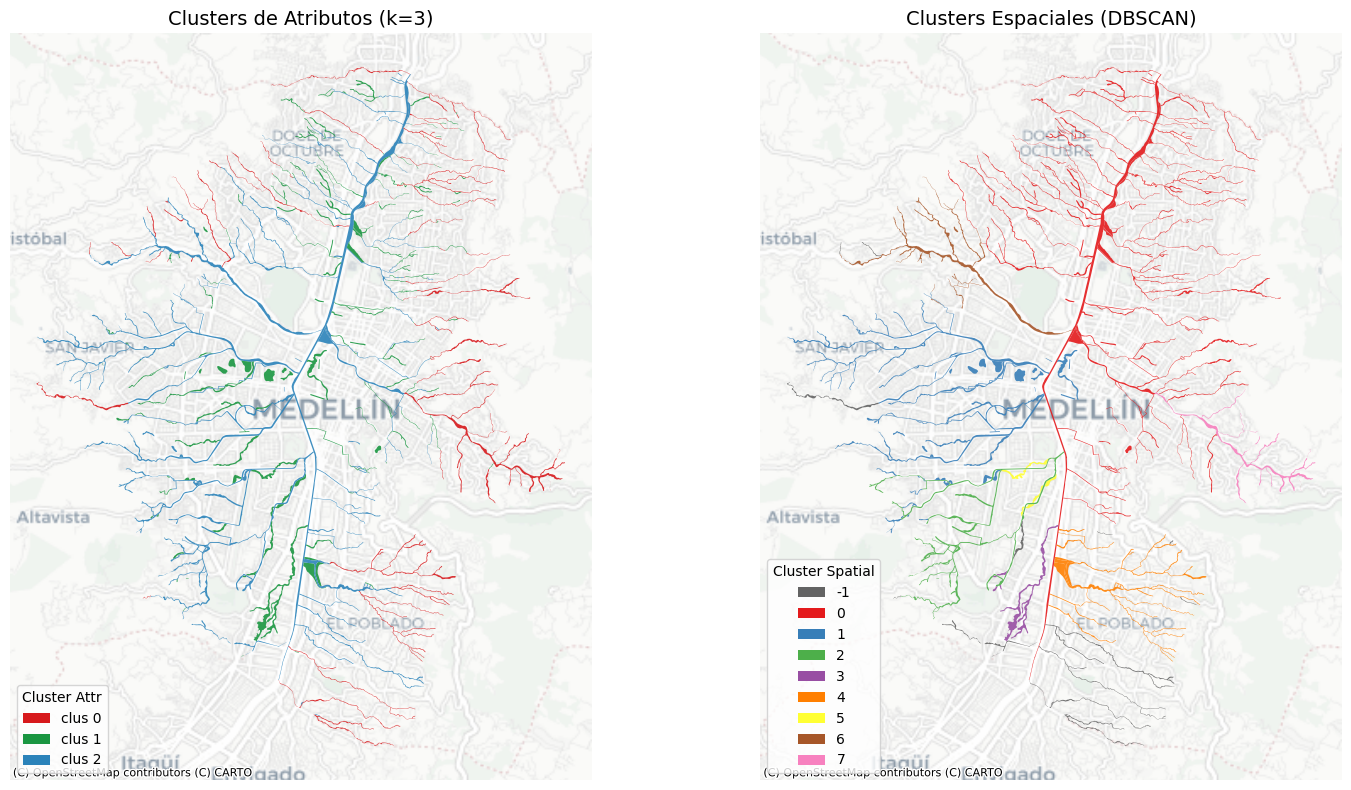

In [4]:
# -------------------------------
import matplotlib.pyplot as plt
import contextily as ctx

# 1) Reproyectar a Web Mercator
gdf_3857 = gdf.to_crs(epsg=3857)

# 2) Definir paletas manuales de alto contraste
#   Para los 3 clusters de atributos
palette_attr = {
    0: "#d7191c",  # rojo fuerte
    1: "#1a9641",  # verde esmeralda
    2: "#2b83ba"   # azul profundo
}

#   Para los 8 clusters espaciales (incluye ruido = -1)
palette_space = {
    -1: "#636363", # gris oscuro para ruido
     0: "#e41a1c",
     1: "#377eb8",
     2: "#4daf4a",
     3: "#984ea3",
     4: "#ff7f00",
     5: "#ffff33",
     6: "#a65628",
     7: "#f781bf"
}

# 3) Plotear clusters de atributos con la paleta contrastante
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

gdf_3857.assign(color=gdf_3857['cluster_attr'].map(palette_attr)) \
    .plot(color=gdf_3857['cluster_attr'].map(palette_attr),
          legend=False, ax=ax[0], linewidth=0.3, alpha=0.9)
ax[0].set_title("Clusters de Atributos (k=3)", fontsize=14)
ax[0].set_axis_off()

# 4) Plotear clusters espaciales a la par
gdf_3857.assign(color=gdf_3857['cluster_spatial'].map(palette_space)) \
    .plot(color=gdf_3857['cluster_spatial'].map(palette_space),
          legend=False, ax=ax[1], linewidth=0.3, alpha=0.9)
ax[1].set_title("Clusters Espaciales (DBSCAN)", fontsize=14)
ax[1].set_axis_off()

# 5) Añadir el mismo basemap a ambos ejes
for a in ax:
    ctx.add_basemap(a, source=ctx.providers.CartoDB.Positron, zoom=12)

# 6) Añadir leyenda manual
#    Creamos parches para cada color
from matplotlib.patches import Patch
legend_attr = [Patch(facecolor=c, label=f"clus {k}") for k,c in palette_attr.items()]
legend_space = [Patch(facecolor=c, label=f"{k}")      for k,c in palette_space.items()]

ax[0].legend(handles=legend_attr, title="Cluster Attr", loc="lower left")
ax[1].legend(handles=legend_space, title="Cluster Spatial", loc="lower left")

plt.tight_layout()
plt.show()

In [5]:
gdf.groupby("cluster_attr")[all_cols].mean()


,Elevacion_,Pendiente_,Aspecto_me,Curvatura_,TPI_mean,TRI_mean,pct_cov_Bo,pct_cov_Su,pct_cov_Te,pct_cov__1,count_even
cluster_attr,,,,,,,,,,,
0,1683.236066,24.039066,219.484667,-0.094236,-6.950431,0.688373,57.509019,0.013672,4.736125,37.741267,0.619469
1,1548.828398,8.253935,186.645980,-0.008102,-2.047207,0.201852,8.645119,0.018286,0.763103,90.573523,0.253731
2,1532.172190,9.831518,177.887507,-0.006417,-2.263576,0.258882,51.762381,0.744553,5.683748,41.825280,0.744000


#  Eventos caen en cada polígono con una distancia máxima de 100 m:

In [4]:
# 1) Cargar inventario de inundaciones y reproyectar
import geopandas as gpd
events = gpd.read_file(r"D:/Semestre 2025-1/Analisis Geoespacial/SHP/Inventario_inundaciones_lluvias_MedellinZonaUrbana.shp")\
           .to_crs(gdf.crs)
print("Eventos cargados:", len(events))

# 2) Spatial join nearest con max_distance=100 m
joined = gpd.sjoin_nearest(
    events[['geometry']],
    gdf[['poly_id','geometry']],
    how="left",
    max_distance=100,
    distance_col="dist"
)

# 3) Contar por polígono y asignar a gdf
counts = joined.groupby('poly_id').size().rename('count100')
gdf['count100'] = gdf['poly_id'].map(counts).fillna(0).astype(int)

# 4) Revisar resumen
print("count100 — resumen:")
print(gdf['count100'].describe())


Eventos cargados: 430
count100 — resumen:
count    506.000000
mean       0.456522
std        1.663554
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       13.000000
Name: count100, dtype: float64


# log1p de count100

In [5]:
# ————————————————————————————————————————————————————————
# 1) Definir variables independientes y respuesta
base_cols = ['Elevacion_', 'Pendiente_', 'Aspecto_me', 'Curvatura_', 'TPI_mean', 'TRI_mean']
cov_cols  = [c for c in gdf.columns if c.startswith('pct_cov_')]
X_vars    = base_cols + cov_cols

import numpy as np
from sklearn.preprocessing import StandardScaler

# Matriz X y estandarización
X_cont = gdf[X_vars].fillna(0).values
Xs     = StandardScaler().fit_transform(X_cont)

# Variable dependiente
y = np.log1p(gdf['count100'].values).reshape(-1, 1)

print("X_vars:", X_vars)
print("Xs shape:", Xs.shape, "y shape:", y.shape)

# 2) Construir matriz de pesos IDW 300 m (row‐standardized)
from libpysal.weights import DistanceBand

coords = np.vstack([gdf.geometry.centroid.x, gdf.geometry.centroid.y]).T
w = DistanceBand.from_array(coords, threshold=300, binary=False, silence_warnings=True)
w.transform = "R"
print("Weights matrix: n_neighbors avg =", np.mean(list(map(len, w.neighbors.values()))))
# ————————————————————————————————————————————————————————


X_vars: ['Elevacion_', 'Pendiente_', 'Aspecto_me', 'Curvatura_', 'TPI_mean', 'TRI_mean', 'pct_cov_Bo', 'pct_cov_Su', 'pct_cov_Te', 'pct_cov__1']
Xs shape: (506, 10) y shape: (506, 1)
Weights matrix: n_neighbors avg = 3.197628458498024


C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\scipy\sparse\_data.py:128: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


# Construir SLX (dummies de KMeans)

In [14]:
# ——————————————————————————————
# (Nueva Celda) SLX: dummies de cluster_attr (k=3) + cast a float
import pandas as pd

# 1) Crear dummies dejando fuera la base (drop_first=True)
dummies = pd.get_dummies(gdf['cluster_attr'], prefix='cluster', drop_first=True)
print("Dummies creadas:", dummies.columns.tolist())

# 2) DataFrame de Xs (escala) con sus nombres
df_Xs = pd.DataFrame(Xs, index=gdf.index, columns=X_vars)

# 3) Concatenar dummies y luego castear TODO a float
df_slx = pd.concat([df_Xs, dummies], axis=1).astype(float)

# 4) Actualizar X_full y lista de nombres
X_vars_slx = df_slx.columns.tolist()
X_full     = df_slx.values  # ahora float64 puro

print("Variables finales SLX:", X_vars_slx)
print("X_full SLX shape:", X_full.shape)
# ——————————————————————————————


Dummies creadas: ['cluster_1', 'cluster_2']
Variables finales SLX: ['Elevacion_', 'Pendiente_', 'Aspecto_me', 'Curvatura_', 'TPI_mean', 'TRI_mean', 'pct_cov_Bo', 'pct_cov_Su', 'pct_cov_Te', 'pct_cov__1', 'cluster_1', 'cluster_2']
X_full SLX shape: (506, 12)


# Ajustar SAR+SLX y CAR+SLX

In [15]:
# ——————————————————————————————
# (Nueva Celda) Ajustar SAR+SLX y CAR+SLX
from spreg import ML_Lag, ML_Error

# 1) SAR + SLX
sar_slx = ML_Lag(
    y,                # tu vector dependiente (log1p(count100))
    X_full,           # matriz con dummies incluida
    w=w,              # tu matriz de pesos (IDW300m row‐standardized)
    name_y='log1p(count100)',
    name_x=X_vars_slx,
    name_w='w_IDW300m',
    name_ds='Amenaza_SAR_SLX'
)
print("\n=== SAR + SLX ===")
print(sar_slx.summary)

# 2) CAR + SLX
car_slx = ML_Error(
    y,
    X_full,
    w=w,
    name_y='log1p(count100)',
    name_x=X_vars_slx,
    name_w='w_IDW300m',
    name_ds='Amenaza_CAR_SLX'
)
print("\n=== CAR + SLX ===")
print(car_slx.summary)
# ——————————————————————————————



=== SAR + SLX ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :Amenaza_SAR_SLX
Weights matrix      :   w_IDW300m
Dependent Variable  :log1p(count100)                Number of Observations:         506
Mean dependent var  :      0.1695                Number of Variables   :          14
S.D. dependent var  :      0.4892                Degrees of Freedom    :         492
Pseudo R-squared    :      0.0425
Spatial Pseudo R-squared:  0.0402
Log likelihood      :   -345.1108
Sigma-square ML     :      0.2287                Akaike info criterion :     718.222
S.E of regression   :      0.4782                Schwarz criterion     :     777.393

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
--------------------------------------

C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


# SLX+ESF sobre conteo por red hidŕica

In [36]:
# ——————————————————————————————
# Grafo ultraligero v2: tolerancia 100 m y grilla 50 m

import math
import networkx as nx
from shapely.geometry import LineString
from shapely.ops import unary_union
streams = gpd.read_file("D:\Semestre 2025-1\Analisis Geoespacial\SHP\Red_hidrica_Medellin_ZonaUrbana.shp")
# 1) Simplificar a 100 m
streams_s = streams.geometry.simplify(tolerance=100)

# 2) Unir en un solo MultiLineString
merged = unary_union(streams_s)

# 3) Crear grafo con nodos “snap” a 50 m
G = nx.Graph()
def snap(pt, grid=50):
    return (round(pt[0]/grid)*grid, round(pt[1]/grid)*grid)

# iterable de segmentos
geoms = [merged] if isinstance(merged, LineString) else merged.geoms
for line in geoms:
    coords = list(line.coords)
    for (x1,y1),(x2,y2) in zip(coords[:-1], coords[1:]):
        u = snap((x1,y1)); v = snap((x2,y2))
        d = math.hypot(x2-x1, y2-y1)
        G.add_edge(u, v, weight=d)

print("Grafo ultraligero v2: nodes =", len(G), "edges =", G.size())


<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_38452\3648737270.py:8: SyntaxWarning: invalid escape sequence '\S'
  streams = gpd.read_file("D:\Semestre 2025-1\Analisis Geoespacial\SHP\Red_hidrica_Medellin_ZonaUrbana.shp")


Grafo ultraligero v2: nodes = 1922 edges = 1960


In [37]:
# 4) Crear KDTree de nodos y mapear centroides de polígonos
import numpy as np
from scipy.spatial import cKDTree

# 4.1) Extraemos los nodos de G y montamos el KDTree
nodes = np.array(list(G.nodes))
tree  = cKDTree(nodes)

# 4.2) Para cada polígono, guardamos (nodo más cercano, distancia euclidiana)
poly_centroids = gdf.geometry.centroid
poly_nodes = []
for pt in poly_centroids:
    d, idx = tree.query((pt.x, pt.y))
    poly_nodes.append((tuple(nodes[idx]), d))

# 4.3) Comprobamos las primeras asignaciones
print("Primeros 5 polígonos → (nodo, dist):")
for i, (n, d) in enumerate(poly_nodes[:5]):
    print(f"  poly {i}: nodo={n}, dist={d:.1f} m")


Primeros 5 polígonos → (nodo, dist):
  poly 0: nodo=(4715550, 2251000), dist=256.3 m
  poly 1: nodo=(4715800, 2252200), dist=204.6 m
  poly 2: nodo=(4715400, 2252050), dist=191.9 m
  poly 3: nodo=(4716050, 2252600), dist=51.7 m
  poly 4: nodo=(4715550, 2252900), dist=207.2 m


In [38]:
import pandas as pd

# 5) Snap de eventos al nodo más cercano
event_nodes = []
event_dists = []
for pt in events.geometry:
    d_ev, idx_ev = tree.query((pt.x, pt.y))
    n_ev = tuple(nodes[idx_ev])
    event_nodes.append((n_ev, d_ev))

# 6) Para cada evento, encontrar el polígono con menor distancia de red
assign = []  # aquí guardaremos el índice del polígono asignado
for (n_ev, d_ev) in event_nodes:
    best_idx, best_d = None, np.inf
    for i, (n_poly, d_poly) in enumerate(poly_nodes):
        try:
            d_net = nx.shortest_path_length(G, n_ev, n_poly, weight='weight')
        except nx.NetworkXNoPath:
            continue
        total_dist = d_ev + d_net + d_poly
        if total_dist < best_d:
            best_idx, best_d = i, total_dist
    assign.append(best_idx)

# 7) Contar cuántos eventos por polígono y volcar a gdf
counts = pd.Series(assign).value_counts().sort_index()
gdf['count_net'] = counts.reindex(range(len(gdf)), fill_value=0).values

# 8) Revisar estadísticos
print(gdf['count_net'].describe())


count    506.000000
mean       0.762846
std        3.418511
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       67.000000
Name: count_net, dtype: float64


In [30]:
# --- Modelos SAR y CAR con count_net ---
from sklearn.preprocessing import StandardScaler
from libpysal.weights import DistanceBand
from spreg import ML_Lag, ML_Error
import numpy as np

# 1) Definir variables
base_cols = ['Elevacion_','Pendiente_','Aspecto_me','Curvatura_','TPI_mean','TRI_mean']
cov_cols  = [c for c in gdf.columns if c.startswith('pct_cov_')]
X_cols    = base_cols + cov_cols

# 2) Preparar X y y
X = gdf[X_cols].fillna(0).values
Xs = StandardScaler().fit_transform(X)
y  = np.log1p(gdf['count_net'].values.reshape(-1,1))

print("Variables X:", X_cols)
print("Xs shape:", Xs.shape, "y shape:", y.shape)

# 3) Matriz espacial IDW 300 m row‐standardized
coords = np.vstack([gdf.geometry.centroid.x, gdf.geometry.centroid.y]).T
w      = DistanceBand.from_array(coords, threshold=300, binary=False, silence_warnings=True)
w.transform = "R"

# 4) Ajustar Spatial Lag (SAR)
sar = ML_Lag(
    y, Xs, w=w,
    name_y='log1p(count_net)',
    name_x=X_cols,
    name_w='w_IDW300m',
    name_ds='Amenaza_SAR'
)
print("\n=== SAR ===")
print(sar.summary)

# 5) Ajustar Spatial Error (CAR)
car = ML_Error(
    y, Xs, w=w,
    name_y='log1p(count_net)',
    name_x=X_cols,
    name_w='w_IDW300m',
    name_ds='Amenaza_CAR'
)
print("\n=== CAR ===")
print(car.summary)


Variables X: ['Elevacion_', 'Pendiente_', 'Aspecto_me', 'Curvatura_', 'TPI_mean', 'TRI_mean', 'pct_cov_Bo', 'pct_cov_Su', 'pct_cov_Te', 'pct_cov__1']
Xs shape: (506, 10) y shape: (506, 1)

=== SAR ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            : Amenaza_SAR
Weights matrix      :   w_IDW300m
Dependent Variable  :log1p(count_net)                Number of Observations:         506
Mean dependent var  :      0.2589                Number of Variables   :          12
S.D. dependent var  :      0.5845                Degrees of Freedom    :         494
Pseudo R-squared    :      0.0310
Spatial Pseudo R-squared:  0.0304
Log likelihood      :   -438.1019
Sigma-square ML     :      0.3304                Akaike info criterion :     900.204
S.E of regression   :      0.5748                Schwarz criterion     :     950.922

----------------------------

C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\scipy\sparse\_data.py:128: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


## Calcular y añadir los primeros autovectores de Moran (ESF)

In [31]:
# 1.1) Obtener la matriz densa W (IDW300m)
W_mat, _ = w.full()

# 1.2) Centrar W: M = I - (1/n)·11ᵀ
n = W_mat.shape[0]
I = np.eye(n)
J = np.ones((n, n)) / n
M = I - J

# 1.3) Matriz centrada C = M·W·M y descomposición
C = M.dot(W_mat).dot(M)
eigs, vecs = np.linalg.eigh(C)

# 1.4) Seleccionar los k primeros EV con eigenvalor > 0
pos = eigs > 1e-6
order = np.argsort(eigs[pos])[::-1]
k    = min(10, order.size)
E    = vecs[:, pos][:, order[:k]]
EVs  = [f"EV_{i+1}" for i in range(k)]

# 1.5) Construir X_esf (Xs + E)
X_esf      = np.hstack([Xs, E])
X_vars_esf = X_cols + EVs

print("Incluimos autovectores:", EVs)
print("X_esf shape:", X_esf.shape)


Incluimos autovectores: ['EV_1', 'EV_2', 'EV_3', 'EV_4', 'EV_5', 'EV_6', 'EV_7', 'EV_8', 'EV_9', 'EV_10']
X_esf shape: (506, 20)


## Ajustar SAR + ESF y CAR + ESF

In [32]:
# 2.1) SAR + ESF
sar_esf = ML_Lag(
    y, X_esf, w=w,
    name_y='log1p(count_net)',
    name_x=X_vars_esf,
    name_w='w_IDW300m',
    name_ds='Amenaza_SAR_ESF',
    inv_method='true_inv'   # para evitar problemas de convergencia
)
print("\n=== SAR + ESF ===")
print(sar_esf.summary)

# 2.2) CAR + ESF
car_esf = ML_Error(
    y, X_esf, w=w,
    name_y='log1p(count_net)',
    name_x=X_vars_esf,
    name_w='w_IDW300m',
    name_ds='Amenaza_CAR_ESF'
)
print("\n=== CAR + ESF ===")
print(car_esf.summary)



=== SAR + ESF ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :Amenaza_SAR_ESF
Weights matrix      :   w_IDW300m
Dependent Variable  :log1p(count_net)                Number of Observations:         506
Mean dependent var  :      0.2589                Number of Variables   :          22
S.D. dependent var  :      0.5845                Degrees of Freedom    :         484
Pseudo R-squared    :      0.0570
Spatial Pseudo R-squared:  0.0522
Log likelihood      :   -431.7107
Sigma-square ML     :      0.3216                Akaike info criterion :     907.421
S.E of regression   :      0.5671                Schwarz criterion     :    1000.405

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------

C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


# ESF: extraer EV y volver a ajustar SAR+ESF / CAR+ESF

In [16]:
# ——————————————————————————————
# (Nueva Celda) ESF: extraer EV y volver a ajustar SAR+ESF / CAR+ESF
import numpy as np
from libpysal.weights import DistanceBand
from spreg import ML_Lag, ML_Error
from sklearn.preprocessing import StandardScaler

# 1) Definimos W (ya row-standardized en SLX)
coords = np.vstack([gdf.geometry.centroid.x, gdf.geometry.centroid.y]).T
w      = DistanceBand.from_array(coords, threshold=300, binary=False, silence_warnings=True)
w.transform = "R"

# 2) Matriz densa y centrar: C = M W M
Wmat, _ = w.full()
n       = Wmat.shape[0]
I       = np.eye(n)
J       = np.ones((n,n)) / n
M       = I - J
C       = M.dot(Wmat).dot(M)

# 3) Descomposición y selección de EV positivos (top 10)
eigs, vecs = np.linalg.eigh(C)
mask      = eigs > 1e-6
pos_vals  = eigs[mask]
pos_vecs  = vecs[:,mask]
order     = np.argsort(pos_vals)[::-1]
k_eig     = min(10, len(pos_vals))
E         = pos_vecs[:, order[:k_eig]]
EV_names  = [f"EV_{i+1}" for i in range(k_eig)]

# 4) Construir X_esf: tomamos tu X_full SLX (Xs + dummies) y le pegamos E
#    Asumo que en la celda SLX tuvimos:
#       df_slx (DataFrame float64) y X_full = df_slx.values
X_esf     = np.hstack([X_full, E])
X_vars_esf = X_vars_slx + EV_names

print("X_esf shape:", X_esf.shape, "Variables ESF:", X_vars_esf)

# 5) Ajustar SAR + ESF
sar_esf = ML_Lag(
    y,                 # log1p(count100)
    X_esf,
    w=w,
    name_y='log1p(count100)',
    name_x=X_vars_esf,
    name_w='w_IDW300m',
    name_ds='Amenaza_ESF'
)
print("\n=== SAR + ESF ===")
print(sar_esf.summary)

# 6) Ajustar CAR + ESF
car_esf = ML_Error(
    y,
    X_esf,
    w=w,
    name_y='log1p(count100)',
    name_x=X_vars_esf,
    name_w='w_IDW300m',
    name_ds='Amenaza_ESF'
)
print("\n=== CAR + ESF ===")
print(car_esf.summary)
# ——————————————————————————————


X_esf shape: (506, 22) Variables ESF: ['Elevacion_', 'Pendiente_', 'Aspecto_me', 'Curvatura_', 'TPI_mean', 'TRI_mean', 'pct_cov_Bo', 'pct_cov_Su', 'pct_cov_Te', 'pct_cov__1', 'cluster_1', 'cluster_2', 'EV_1', 'EV_2', 'EV_3', 'EV_4', 'EV_5', 'EV_6', 'EV_7', 'EV_8', 'EV_9', 'EV_10']

=== SAR + ESF ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            : Amenaza_ESF
Weights matrix      :   w_IDW300m
Dependent Variable  :log1p(count100)                Number of Observations:         506
Mean dependent var  :      0.1695                Number of Variables   :          24
S.D. dependent var  :      0.4892                Degrees of Freedom    :         482
Pseudo R-squared    :      0.0530
Spatial Pseudo R-squared:  0.0492
Log likelihood      :   -342.4840
Sigma-square ML     :      0.2262                Akaike info criterion :     732.968
S.E of regressi

C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\scipy\sparse\_data.py:128: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


# SAR y CAR

In [10]:
# ————————————————————————————————————————————————————————
# 3) Ajuste de Spatial Lag Model (SAR)
from spreg import ML_Lag

sar = ML_Lag(
    y, Xs, w=w,
    name_y='log1p(count100)',
    name_x=X_vars,
    name_w='w_IDW300m',
    name_ds='Amenaza_SAR'
)
print("=== SAR ===")
print(sar.summary)

# 4) Ajuste de Spatial Error Model (CAR)
from spreg import ML_Error

car = ML_Error(
    y, Xs, w=w,
    name_y='log1p(count100)',
    name_x=X_vars,
    name_w='w_IDW300m',
    name_ds='Amenaza_CAR'
)
print("\n=== CAR ===")
print(car.summary)
# ————————————————————————————————————————————————————————


=== SAR ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            : Amenaza_SAR
Weights matrix      :   w_IDW300m
Dependent Variable  :log1p(count100)                Number of Observations:         506
Mean dependent var  :      0.1695                Number of Variables   :          12
S.D. dependent var  :      0.4892                Degrees of Freedom    :         494
Pseudo R-squared    :      0.0297
Spatial Pseudo R-squared:  0.0256
Log likelihood      :   -348.5595
Sigma-square ML     :      0.2318                Akaike info criterion :     721.119
S.E of regression   :      0.4814                Schwarz criterion     :     771.837

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------

C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(



=== CAR ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
---------------------------------------------------
Data set            : Amenaza_CAR
Weights matrix      :   w_IDW300m
Dependent Variable  :log1p(count100)                Number of Observations:         506
Mean dependent var  :      0.1695                Number of Variables   :          11
S.D. dependent var  :      0.4892                Degrees of Freedom    :         495
Pseudo R-squared    :      0.0243
Log likelihood      :   -348.8519
Sigma-square ML     :      0.2322                Akaike info criterion :     719.704
S.E of regression   :      0.4818                Schwarz criterion     :     766.196

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT    

# GWR

In [47]:
# 5) Preparar coordenadas para GWR
import numpy as np
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW

# Extraer coordenadas de los centroides
u = gdf.geometry.centroid.x.values
v = gdf.geometry.centroid.y.values
coords = np.column_stack((u, v))

# Seleccionar bandwidth óptimo (Kernel adaptativo por defecto)
selector = Sel_BW(coords, y, Xs, spherical=False)
bw = selector.search(bw_min=50)   # puedes ajustar bw_min/bw_max
print("Bandwidth óptimo GWR:", bw)


Bandwidth óptimo GWR: 504.0


In [59]:
# 6) Ajuste del modelo GWR
gwr_model = GWR(coords, y, Xs, bw=bw, fixed=False, kernel='gaussian').fit()
print(gwr_model.summary())
# 4) Guardar R² local y residuos del GWR en el GeoDataFrame
gdf['local_R2']   = gwr_model.localR2
gdf['resid_gwr']  = gwr_model.resid_response.flatten()


Model type                                                         Gaussian
Number of observations:                                                 506
Number of covariates:                                                    11

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            117.916
Log-likelihood:                                                    -349.472
AIC:                                                                720.943
AICc:                                                               723.576
BIC:                                                              -2964.220
R2:                                                                   0.024
Adj. R2:                                                              0.005

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

<Axes: >

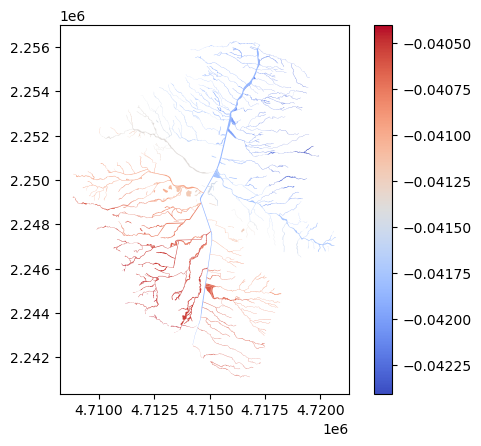

In [49]:
# 7) Añadir coeficientes locales al GeoDataFrame
for i, name in enumerate(X_vars):
    gdf[f"coef_{name}"] = gwr_model.params[:, i+1]  # +1 porque params[:,0] es intercepto

# Por ejemplo, muestreamos coeficiente de 'Elevacion_'
gdf.plot(column='coef_Elevacion_', cmap='coolwarm', legend=True)


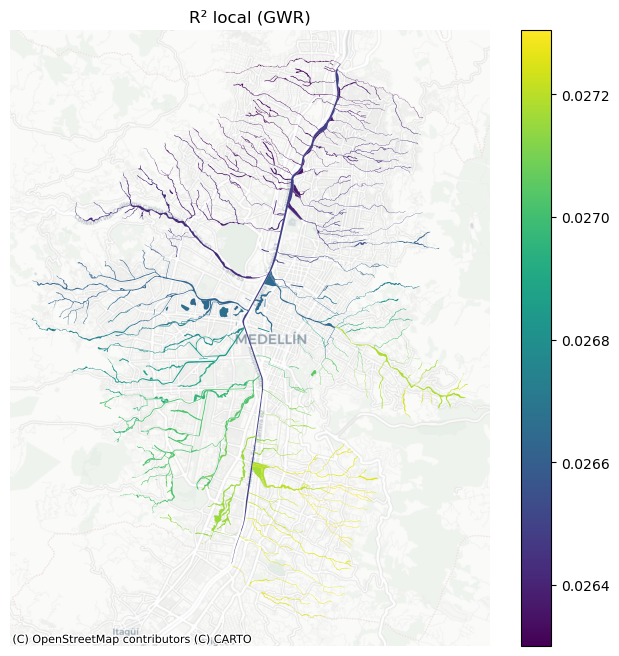

In [55]:
# 8) Mapear R² local de GWR
gdf= gdf.to_crs(epsg=3857)
gdf['localR2'] = gwr_model.localR2
fig, ax = plt.subplots(1,1, figsize=(8,8))
gdf.plot(column='localR2', 
         cmap='viridis', 
         legend=True, 
         linewidth=0.5, 
         ax=ax)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("R² local (GWR)")
plt.show()

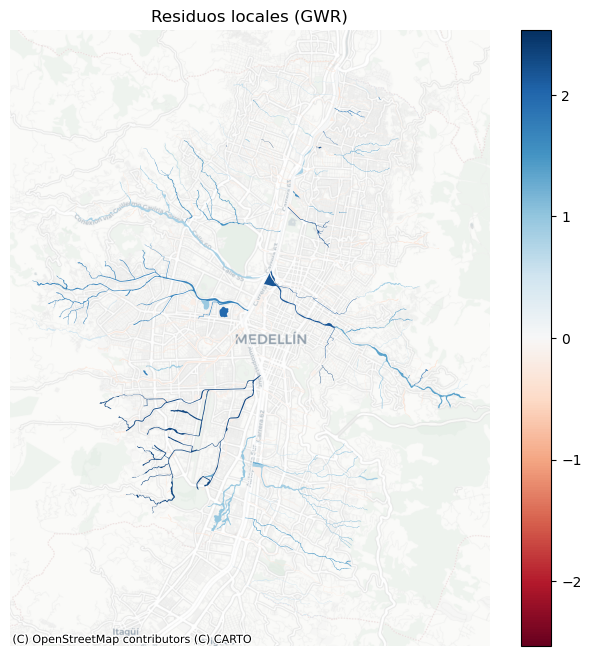

Moran’s I residuos GWR: I=-0.054, p=0.119


In [54]:
# — Nueva celda justo después de la GWR —
import matplotlib.pyplot as plt
import contextily as ctx
from esda.moran import Moran

# 1) Extraer residuos correctos
gdf['resid_gwr'] = gwr_model.resid_response.flatten()

# 2) Mapear residuos sobre basemap
fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(
    column='resid_gwr',
    cmap='RdBu',
    vmin=-gdf['resid_gwr'].abs().max(),
    vmax= gdf['resid_gwr'].abs().max(),
    legend=True,
    linewidth=0.3,
    ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Residuos locales (GWR)")
plt.show()

# 3) Moran’s I de residuos
m_res = Moran(gdf['resid_gwr'], w)
print(f"Moran’s I residuos GWR: I={m_res.I:.3f}, p={m_res.p_sim:.3f}")


Moran's I residuos GWR: I=-0.054, p=0.113


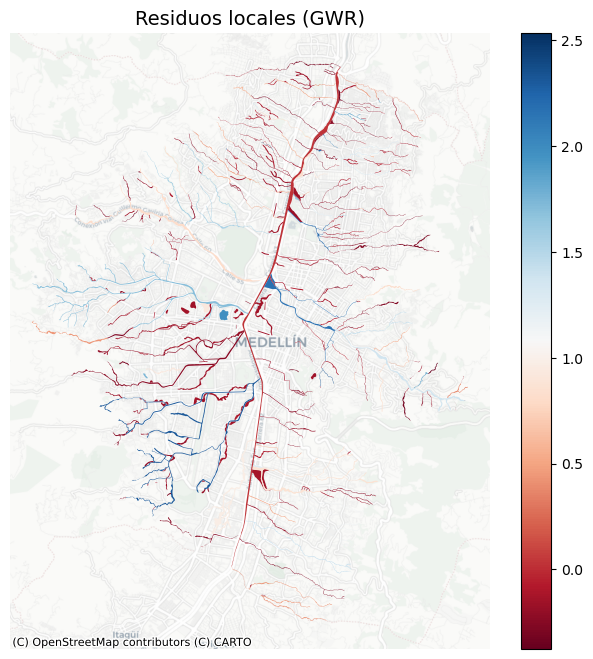

In [56]:
# 5) Mapear residuos locales y Moran’s I
import contextily as ctx
from esda.moran import Moran
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1, figsize=(8,8))
gdf.plot(
    column='resid_gwr',
    cmap='RdBu',
    legend=True,
    linewidth=0.3,
    ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Residuos locales (GWR)", fontsize=14)

m_res = Moran(gdf['resid_gwr'].values, w)
print(f"Moran's I residuos GWR: I={m_res.I:.3f}, p={m_res.p_sim:.3f}")


In [63]:
# --- 8) Guardar coeficiente local de pct_cov_Te ---
# Encuentra el índice de esa variable en tu X_vars (en el orden que usaste al ajustar)
idx = X_vars.index('pct_cov_Te')  # Ej: si X_vars = ['Elevacion_','Pendiente_',...,'pct_cov_Te',...]
# En GWRResults.params la columna 0 es el intercepto, luego vienen las covariables en el mismo orden de X_vars
gdf['beta_pct_cov_Te'] = gwr_model.params[:, idx+1].flatten()


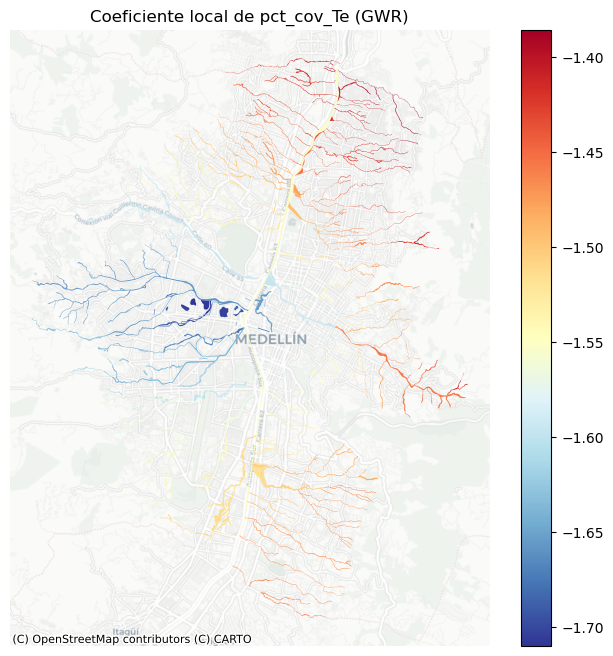

In [64]:
# --- 9) Mapa del coeficiente local de pct_cov_Te ---
fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(
    column='beta_pct_cov_Te',
    cmap='RdYlBu_r',
    legend=True,
    linewidth=0.3,
    ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Coeficiente local de pct_cov_Te (GWR)")
plt.show()


In [58]:
# — Celda nueva para GWR con bw fijo y constante —

import numpy as np
from mgwr.gwr import GWR

# 1) Prepara coordenadas (igual que antes):
coords = np.vstack([gdf.geometry.centroid.x, gdf.geometry.centroid.y]).T

# 2) Define y como vector columna:
y = np.log1p(gdf['count100'].values).reshape((-1,1))

# 3) Usa tu X_full final (shape 506×10) tal cual:
X = X_full  

print("coords:", coords.shape, " y:", y.shape, "  X:", X.shape)

# 4) Fija bandwidth al valor que ya habías usado (~504 ó 505):
bw = 505

# 5) Ajusta GWR incluyendo intercept:
gwr = GWR(coords, y, X, bw,
          fixed=False,
          kernel='gaussian',
          constant=True)      
gwr_res = gwr.fit()

print(gwr_res.summary())

# 6) Almacena R² local y residuos:
gdf['local_R2']  = gwr_res.localR2
gdf['resid_gwr'] = gwr_res.resid_response.flatten()

# 7) Moran’s I sobre residuos (opcional):
from esda.moran import Moran
mi = Moran(gdf['resid_gwr'].values, w)
print(f"Moran's I residuos GWR: I={mi.I:.3f}, p={mi.p_sim:.3f}")


coords: (506, 2)  y: (506, 1)   X: (506, 10)
Model type                                                         Gaussian
Number of observations:                                                 506
Number of covariates:                                                    11

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            117.916
Log-likelihood:                                                    -349.472
AIC:                                                                720.943
AICc:                                                               723.576
BIC:                                                              -2964.220
R2:                                                                   0.024
Adj. R2:                                                              0.005

Variable                              Est.         SE  t(Est/SE)    p-value
---------------

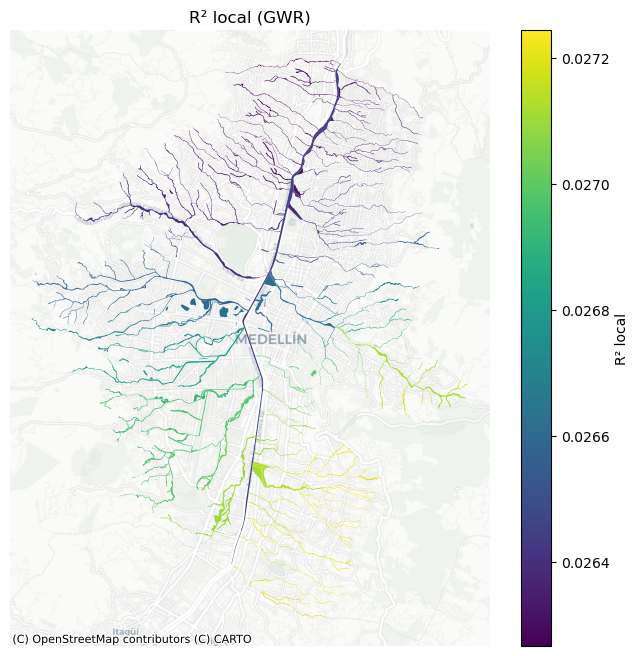

In [74]:
# — Mapa de R² local GWR —
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
gdf.plot(
    column='local_R2',
    cmap='viridis',
    legend=True,
    legend_kwds={'label': "R² local"},
    linewidth=0.3,
    ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("R² local (GWR)")
ax.set_axis_off()
plt.show()


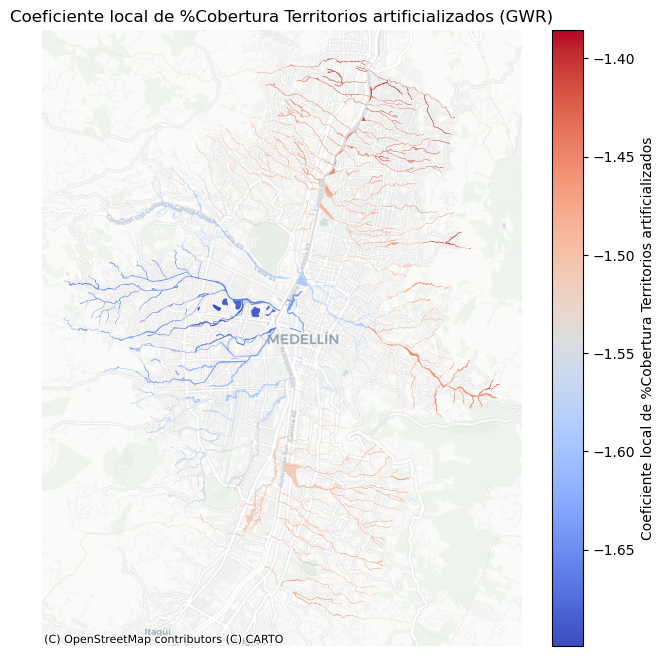

In [62]:
# — Mapa del coeficiente local de pct_cov_Te (GWR) —
import matplotlib.pyplot as plt
import contextily as ctx

# 1) Extraemos el índice de pct_cov_Te en X_vars (0 = intercepto, 1 = Elevacion_, …)
idx = X_vars.index('pct_cov_Te') + 1

# 2) Guardamos en el GeoDataFrame la columna de coeficientes locales
gdf['coef_pct_cov_Te'] = gwr_model.params[:, idx]

# 3) Dibujamos el mapa
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
gdf.plot(
    column='coef_pct_cov_Te',
    cmap='coolwarm',
    legend=True,
    legend_kwds={'label': "Coeficiente local de %Cobertura Territorios artificializados"},
    linewidth=0.3,
    ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Coeficiente local de %Cobertura Territorios artificializados (GWR)")
ax.set_axis_off()
plt.show()


# SAR y CAR con Spatial Regimes

In [7]:
# — Celda auto‐contenida: SAR y CAR con Spatial Regimes —
import numpy as np
from sklearn.preprocessing import StandardScaler
from libpysal.weights import DistanceBand
from spreg import ML_Lag, ML_Error

# 1) Respuesta log-transformada
y_log = np.log1p(gdf['count100'].values).reshape(-1,1)
print("y_log shape:", y_log.shape)

# 2) Listas de predictores
base       = ['Elevacion_','Pendiente_','Aspecto_me','Curvatura_','TPI_mean','TRI_mean']
cov        = [c for c in gdf.columns if c.startswith('pct_cov_')]
# Si tienes dummies de cluster_attr, inclúyelas aquí; 
# si no, déjalo vacío:
dummy_cols = []  # o p.ej. ['cluster_1','cluster_2'] si ya las creaste

feature_names = base + cov + dummy_cols
print("Features:", feature_names)

# 3) Construir X_full idéntico al que usas arriba
X_cont = gdf[base + cov].fillna(0).values
Xs     = StandardScaler().fit_transform(X_cont)
X_full = np.hstack([Xs, gdf[dummy_cols].values]) if dummy_cols else Xs
print("X_full.shape:", X_full.shape)

# 4) Definir matriz de pesos IDW 300 m
coords = np.vstack([gdf.geometry.centroid.x, gdf.geometry.centroid.y]).T
w      = DistanceBand.from_array(coords, threshold=300, binary=False, silence_warnings=True)
w.transform = "R"

# 5) Definir regímenes (0,1,2…) desde tu cluster
regimes = gdf['cluster_attr'].astype(int).values
print("Regímenes:", np.unique(regimes))

# 6) Preparar name_x con intercepto + cada feature
name_x_reg = ['Constant'] + feature_names
print("name_x_reg length:", len(name_x_reg), " vs X_full.shape[1]:", X_full.shape[1])

# 7) Ajustar SAR con spatial regimes
sar_reg = ML_Lag(
    y=y_log,
    x=X_full,
    w=w,
    regimes=regimes,
    name_y='log1p(count100)',
    name_x=name_x_reg,
    name_w='w_IDW300m',
    name_ds='Amenaza_SAR_Reg'
)
print("\n=== SAR con Spatial Regimes ===")
print(sar_reg.summary)

# 8) Ajustar CAR con spatial regimes
car_reg = ML_Error(
    y=y_log,
    x=X_full,
    w=w,
    regimes=regimes,
    name_y='log1p(count100)',
    name_x=name_x_reg,
    name_w='w_IDW300m',
    name_ds='Amenaza_CAR_Reg'
)
print("\n=== CAR con Spatial Regimes ===")
print(car_reg.summary)


y_log shape: (506, 1)
Features: ['Elevacion_', 'Pendiente_', 'Aspecto_me', 'Curvatura_', 'TPI_mean', 'TRI_mean', 'pct_cov_Bo', 'pct_cov_Su', 'pct_cov_Te', 'pct_cov__1']
X_full.shape: (506, 10)
Regímenes: [0 1 2]
name_x_reg length: 11  vs X_full.shape[1]: 10


C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\scipy\sparse\_data.py:128: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)



=== SAR con Spatial Regimes ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG - REGIMES (METHOD = full)
---------------------------------------------------------------------------
Data set            :Amenaza_SAR_Reg
Weights matrix      :   w_IDW300m
Dependent Variable  :log1p(count100)                Number of Observations:         506
Mean dependent var  :      0.1695                Number of Variables   :          34
S.D. dependent var  :      0.4892                Degrees of Freedom    :         472
Pseudo R-squared    :      0.1273
Spatial Pseudo R-squared:  0.1272
Log likelihood      :   -321.4580
Sigma-square ML     :      0.2084                Akaike info criterion :     710.916
S.E of regression   :      0.4565                Schwarz criterion     :     854.618

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
----

C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(



=== CAR con Spatial Regimes ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR - REGIMES (METHOD = full)
-------------------------------------------------------------
Data set            :Amenaza_CAR_Reg
Weights matrix      :   w_IDW300m
Dependent Variable  :log1p(count100)                Number of Observations:         506
Mean dependent var  :      0.1695                Number of Variables   :          33
S.D. dependent var  :      0.4892                Degrees of Freedom    :         473
Pseudo R-squared    :      0.1250
Log likelihood      :   -321.7527
Sigma-square ML     :      0.2089                Akaike info criterion :     709.505
S.E of regression   :      0.4571                Schwarz criterion     :     848.981

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------

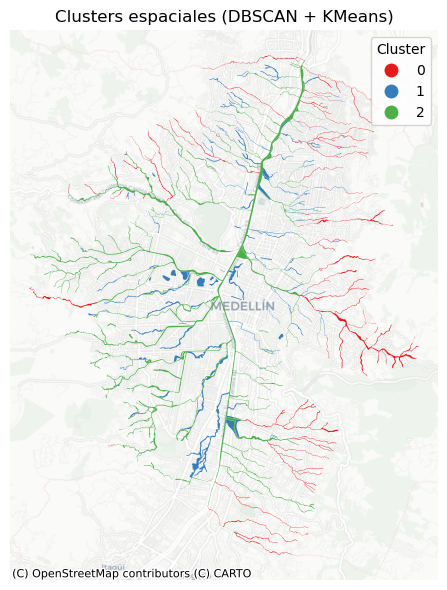

In [57]:
gdf['regime'] = regimes
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Defino un cmap discreto de 3 colores
cmap = ListedColormap(plt.get_cmap('Set1').colors[:3])

fig, ax = plt.subplots(figsize=(6,6))
gdf.plot(
    column='regime',
    categorical=True,
    cmap=cmap,
    legend=True,
    legend_kwds={'title': 'Cluster'},
    linewidth=0.2,
    ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Clusters espaciales (DBSCAN + KMeans)")
ax.set_axis_off()
plt.tight_layout()



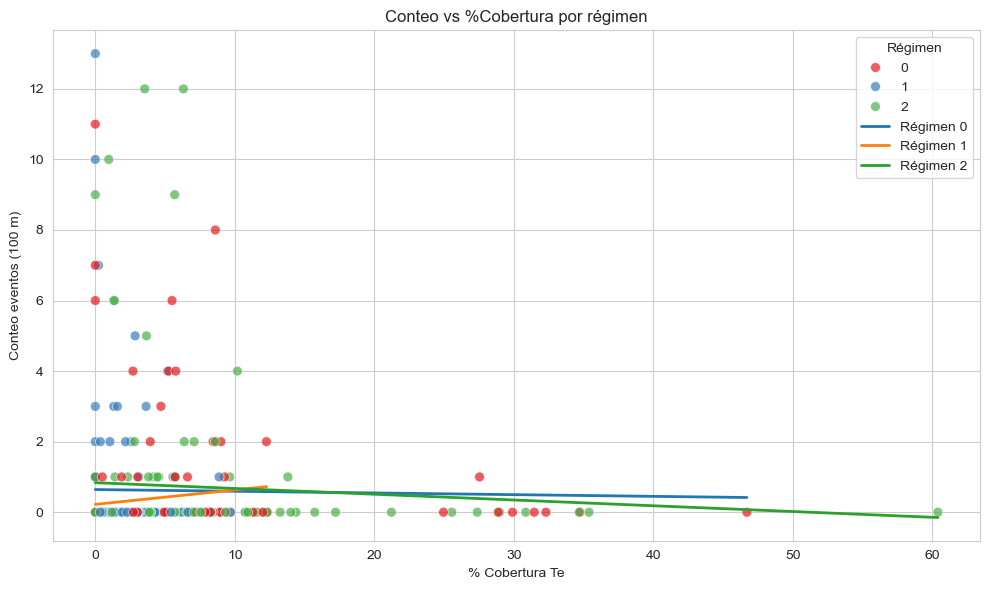

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10,6))

# 1) Puntos
sns.scatterplot(
    data=gdf, 
    x="pct_cov_Te", 
    y="count100", 
    hue="cluster_attr",
    palette="Set1",
    s=50, alpha=0.7,
    ax=ax
)

# 2) Trendlines una a una
for lbl, df_sub in gdf.groupby("cluster_attr"):
    sns.regplot(
        x=df_sub["pct_cov_Te"], 
        y=df_sub["count100"], 
        scatter=False,          # no volver a dibujar puntos
        label=f"Régimen {lbl}",
        ax=ax,
        ci=None,               # sin banda de confianza
        line_kws={"lw":2}
    )

ax.set_xlabel("% Cobertura Te")
ax.set_ylabel("Conteo eventos (100 m)")
ax.set_title("Conteo vs %Cobertura por régimen")
ax.legend(title="Régimen")
plt.tight_layout()
plt.show()


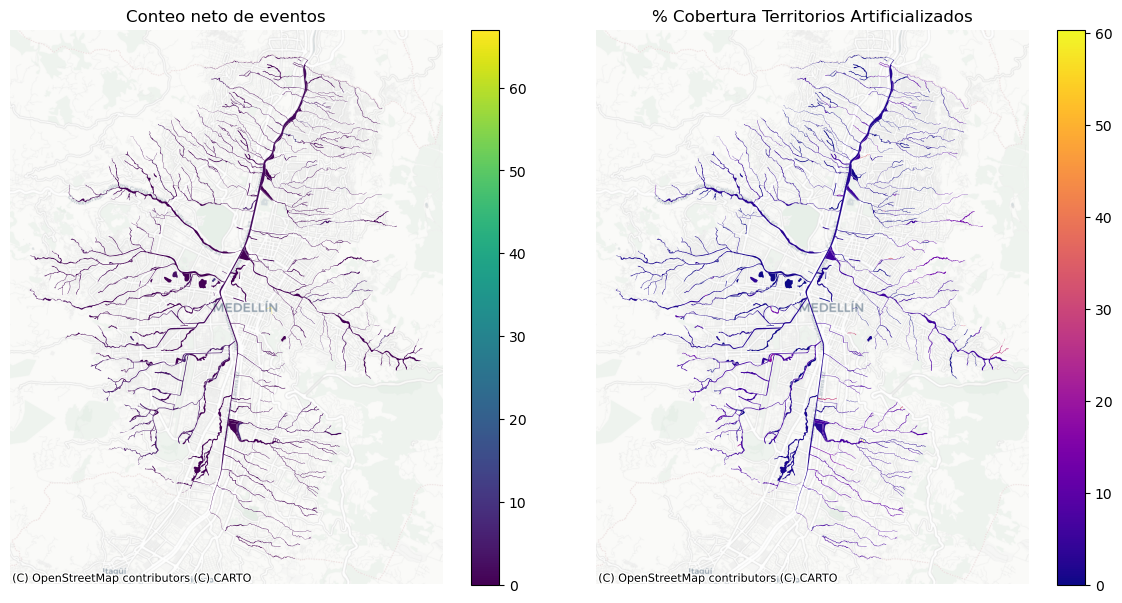

In [53]:
import contextily as ctx
import matplotlib.pyplot as plt
gdf = gdf.to_crs(epsg=3857)
import contextily as ctx

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# a) Mapa de count_net
gdf.plot(
    column='count_net',
    ax=axes[0],
    legend=True,
    cmap='viridis',
    linewidth=0.1
)
# elimina el crs=…, dejamos que ctx tome el CRS del eje
ctx.add_basemap(axes[0], source=ctx.providers.CartoDB.Positron)
axes[0].set_title('Conteo neto de eventos')

# b) Mapa de cobertura Te
gdf.plot(
    column='pct_cov_Te',
    ax=axes[1],
    legend=True,
    cmap='plasma',
    linewidth=0.1
)
ctx.add_basemap(axes[1], source=ctx.providers.CartoDB.Positron)
axes[1].set_title('% Cobertura Territorios Artificializados')

for ax in axes:
    ax.set_axis_off()

plt.tight_layout()
plt.show()


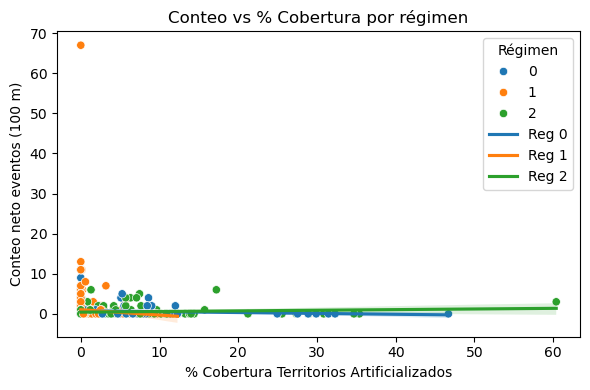

In [42]:
import seaborn as sns

df = gdf.dropna(subset=['pct_cov_Te','count_net','regime'])
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='pct_cov_Te', y='count_net', hue='regime', palette='tab10')
sns.regplot(data=df[df.regime==0], x='pct_cov_Te', y='count_net', scatter=False, label='Reg 0', color='tab:blue')
sns.regplot(data=df[df.regime==1], x='pct_cov_Te', y='count_net', scatter=False, label='Reg 1', color='tab:orange')
sns.regplot(data=df[df.regime==2], x='pct_cov_Te', y='count_net', scatter=False, label='Reg 2', color='tab:green')
plt.legend(title='Régimen')
plt.xlabel('% Cobertura Territorios Artificializados')
plt.ylabel('Conteo neto eventos (100 m)')
plt.title("Conteo vs % Cobertura por régimen")
plt.tight_layout()


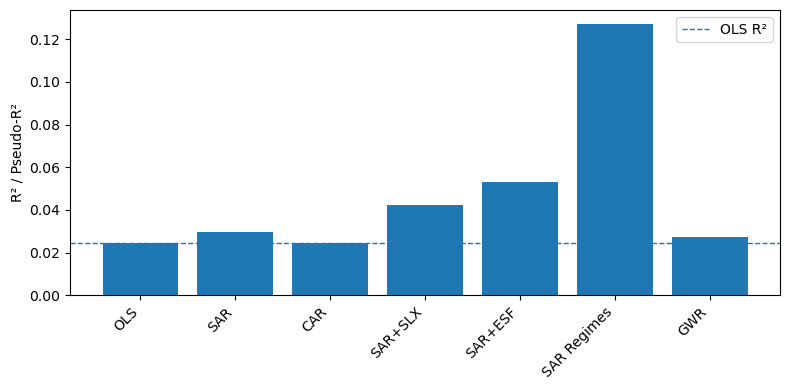

In [64]:
import matplotlib.pyplot as plt

models = ['OLS','SAR','CAR','SAR+SLX','SAR+ESF','SAR Regimes','GWR']
prs   = [0.0243, 0.0297,0.0243,0.,0.0271]

plt.figure(figsize=(8,4))
plt.bar(models, prs)
plt.axhline(0.0243, linestyle='--', label='OLS R²', linewidth=1)
plt.ylabel('R² / Pseudo-R²')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Zonas de susceptibilidad a inundaciones por lluvia')

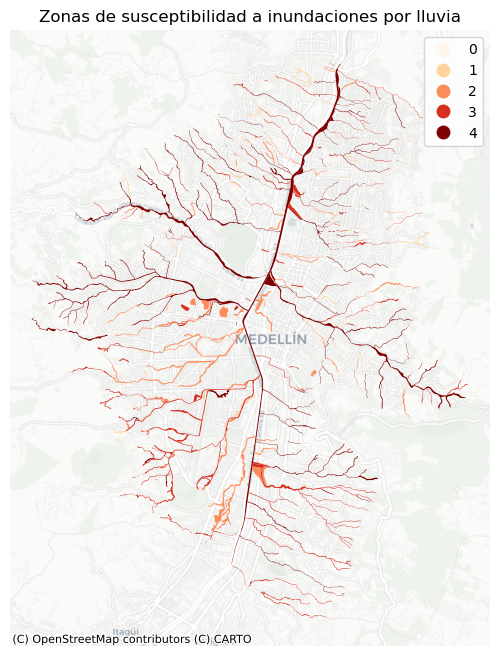

In [69]:
import contextily as ctx
import matplotlib.pyplot as plt
import mapclassify
y_pred = sar_reg.predy_e.flatten()        # predicciones en escala log1p
suscep = np.expm1(y_pred)                 # lo vuelves a escala de conteo
gdf['suscept'] = suscep

breaks = mapclassify.Quantiles(gdf['suscept'], k=5)
gdf['risk_class'] = breaks.yb  # 0–4

fig, ax = plt.subplots(1,1, figsize=(8,8))
gdf.to_crs(epsg=3857).plot(
    column='risk_class',
    categorical=True,
    cmap='OrRd',
    legend=True,
    linewidth=0.2,
    ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Zonas de susceptibilidad a inundaciones por lluvia")
